# Pratica ML

In [ ]:
from sklearn import datasets

iris_X, iris_y = datasets.load_iris(return_X_y=True, as_frame=True)
iris_X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [5]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianNB': GaussianNB()
}

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=0.2, random_state=1)

In [49]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [50]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    results[name] = accuracy_score(y_true=y_test, y_pred=y_predict)

results

{'LogisticRegression': 0.9666666666666667,
 'DecisionTreeClassifier': 0.9666666666666667,
 'KNeighborsClassifier': 1.0,
 'GaussianNB': 0.9666666666666667}

In [54]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Feature Importance**

La feature importance è una tecnica utilizzata per identificare quali caratteristiche (feature) di un dataset hanno il maggiore impatto sulle predizioni di un modello di machine learning. Questo è particolarmente utile per comprendere meglio il modello, migliorare le prestazioni e ridurre la dimensionalità del dataset.

In [55]:
model.feature_importances_

array([0.07086362, 0.02305433, 0.44284721, 0.46323485])

In [56]:
model.feature_names_in_

array(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'], dtype=object)

In [57]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=model.feature_names_in_)
importances

sepal length (cm)    0.070864
sepal width (cm)     0.023054
petal length (cm)    0.442847
petal width (cm)     0.463235
dtype: float64

In [65]:
import numpy as np

std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
std

array([0.1207573 , 0.02886534, 0.30181491, 0.32679282])

Text(0.5, 0, 'Mean decrease in impurity')

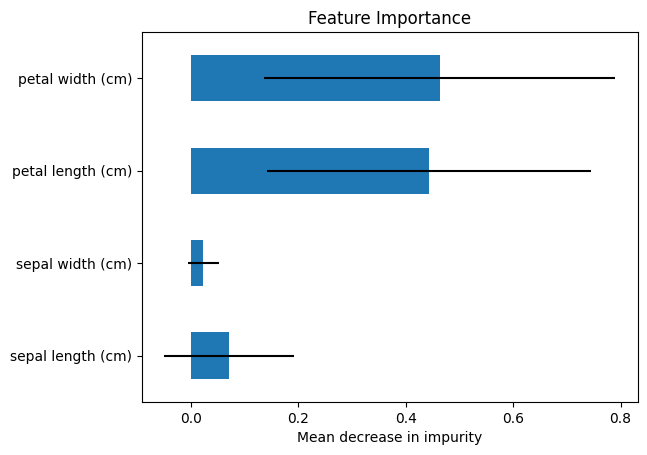

In [66]:
import matplotlib.pyplot as plt
importances.plot.barh(xerr=std)
plt.title("Feature Importance")
plt.xlabel("Mean decrease in impurity")

---

# Titanic: Disaster Survivability